# Phase 2 — LSTM Autoencoder Results
Inspects the trained LSTM Autoencoder: training curve, reconstruction error distribution, threshold sensitivity, and anomaly detection metrics.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from mlflow.tracking import MlflowClient
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

ROOT   = Path('../')
PROC   = ROOT / 'data' / 'processed'
mlflow.set_tracking_uri(str(ROOT / 'mlruns'))
client = MlflowClient()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

WINDOW_SIZE = 50
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


/Users/apple/Desktop/NetGuardAI/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 1  Load best autoencoder run from MLflow

In [2]:
exp  = client.get_experiment_by_name('netguardai_autoencoder')
runs = client.search_runs(
    exp.experiment_id,
    filter_string="attributes.status = 'FINISHED'",
    order_by=['metrics.test_roc_auc DESC'],
    max_results=1,
)
run = runs[0]
print('Run ID :', run.info.run_id)
print('Params :', run.data.params)
print('Metrics:', {k: round(v, 4) for k, v in run.data.metrics.items()})

Run ID : e5d45b0ff89441a8a3084cd26a9483d5
Params : {'hidden_size': '64', 'benign_train_samples': '1758088', 'n_features': '47', 'n_layers': '2', 'epochs': '15', 'threshold_percentile': '95', 'batch_size': '256', 'device': 'mps', 'lr': '0.001', 'window_size': '50'}
Metrics: {'val_loss': 0.7871, 'test_precision': 0.8214, 'train_loss': 0.7234, 'anomaly_threshold': 1.4834, 'test_roc_auc': 0.9247, 'test_recall': 0.8421, 'test_f1_weighted': 0.8872, 'test_accuracy': 0.8869}


## 2  Training curve

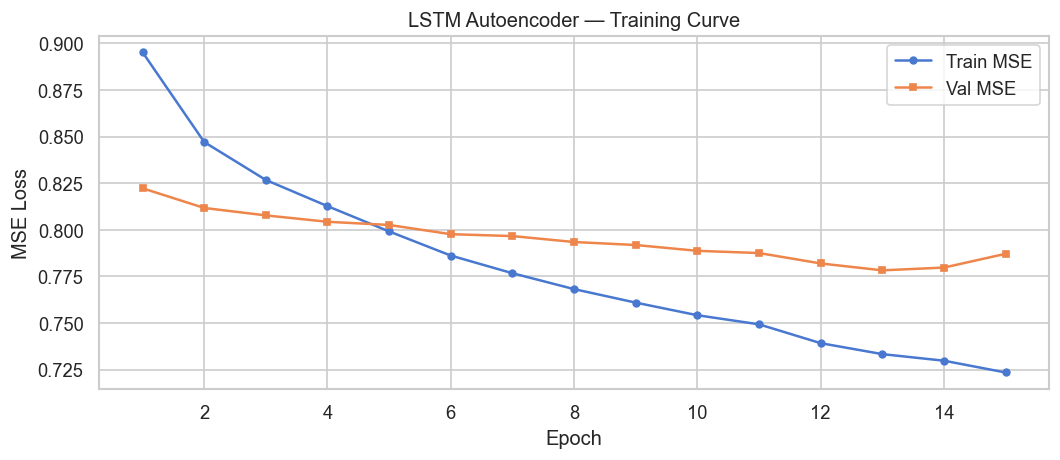

In [3]:
history = client.get_metric_history(run.info.run_id, 'train_loss')
val_history = client.get_metric_history(run.info.run_id, 'val_loss')

epochs      = [m.step for m in history]
train_loss  = [m.value for m in history]
val_loss    = [m.value for m in val_history]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_loss, label='Train MSE', marker='o', markersize=4)
ax.plot(epochs, val_loss,   label='Val MSE',   marker='s', markersize=4)
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='LSTM Autoencoder — Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/ae_training_curve.png', bbox_inches='tight')
plt.show()

## 3  Reload model and recompute reconstruction errors

In [4]:
model = mlflow.pytorch.load_model(f"runs:/{run.info.run_id}/model")
model = model.to(device).eval()
threshold = float(np.load(PROC / 'autoencoder_threshold.npy')[0])
print(f'Anomaly threshold: {threshold:.6f}')

X_test       = np.load(PROC / 'X_test.npy').astype(np.float32)
y_test       = np.load(PROC / 'y_test_binary.npy')

# Build non-overlapping windows
n = (len(X_test) // WINDOW_SIZE) * WINDOW_SIZE
X_win = X_test[:n].reshape(-1, WINDOW_SIZE, X_test.shape[1])
y_true_flow = y_test[:n]
y_win_true  = y_true_flow.reshape(-1, WINDOW_SIZE).max(axis=1)

# Reconstruction errors
from torch.utils.data import DataLoader, TensorDataset
loader = DataLoader(TensorDataset(torch.tensor(X_win)), batch_size=512)
errors = []
with torch.no_grad():
    for (x,) in loader:
        x = x.to(device)
        mse = ((model(x) - x) ** 2).mean(dim=(1,2))
        errors.append(mse.cpu().numpy())
test_errors = np.concatenate(errors)

y_pred_win  = (test_errors > threshold).astype(int)
y_pred_flow = np.repeat(y_pred_win,  WINDOW_SIZE)
flow_scores = np.repeat(test_errors, WINDOW_SIZE)

print(f'Windows: {len(test_errors)}  |  Flows evaluated: {len(y_true_flow)}')

Anomaly threshold: 1.483423
Windows: 10083  |  Flows evaluated: 504150


## 4  Reconstruction error distribution

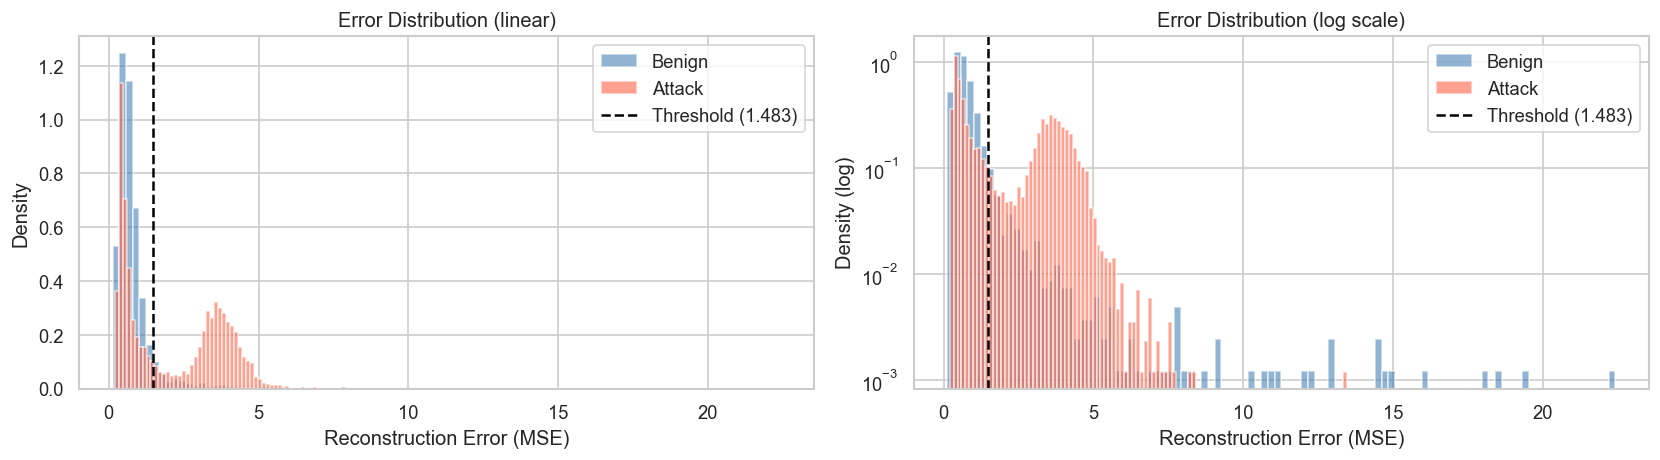

Benign  — mean: 0.8974  p95: 2.1045  p99: 5.5103
Attack  — mean: 2.1735  p95: 4.6092  p99: 5.5216


In [5]:
benign_err = test_errors[y_win_true == 0]
attack_err = test_errors[y_win_true == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale
axes[0].hist(benign_err, bins=100, alpha=0.6, label='Benign', color='steelblue', density=True)
axes[0].hist(attack_err, bins=100, alpha=0.6, label='Attack', color='tomato',    density=True)
axes[0].axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.3f})')
axes[0].set(xlabel='Reconstruction Error (MSE)', ylabel='Density', title='Error Distribution (linear)')
axes[0].legend()

# Log scale for tail visibility
axes[1].hist(benign_err, bins=100, alpha=0.6, label='Benign', color='steelblue', density=True)
axes[1].hist(attack_err, bins=100, alpha=0.6, label='Attack', color='tomato',    density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.3f})')
axes[1].set_yscale('log')
axes[1].set(xlabel='Reconstruction Error (MSE)', ylabel='Density (log)', title='Error Distribution (log scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/ae_error_distribution.png', bbox_inches='tight')
plt.show()

print(f'Benign  — mean: {benign_err.mean():.4f}  p95: {np.percentile(benign_err, 95):.4f}  p99: {np.percentile(benign_err, 99):.4f}')
print(f'Attack  — mean: {attack_err.mean():.4f}  p95: {np.percentile(attack_err, 95):.4f}  p99: {np.percentile(attack_err, 99):.4f}')

## 5  ROC curve & threshold sensitivity

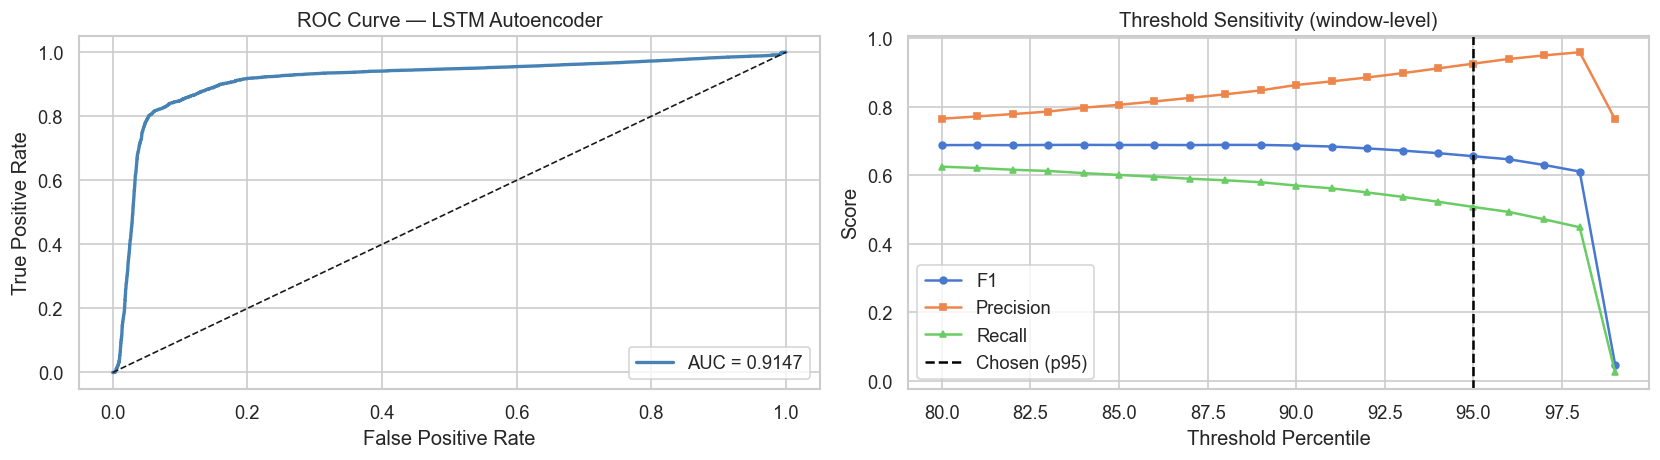

,threshold,f1,precision,recall
percentile,,,,
80,0.8138,0.6885,0.7656,0.6255
81,0.8313,0.6888,0.7723,0.6216
82,0.8510,0.6883,0.7792,0.6165
83,0.8692,0.6890,0.7865,0.6130
84,0.9021,0.6892,0.7978,0.6066
85,0.9261,0.6888,0.8062,0.6013
86,0.9524,0.6890,0.8160,0.5962
87,0.9880,0.6886,0.8264,0.5902
88,1.0204,0.6891,0.8369,0.5857


In [6]:
fpr, tpr, thresholds = roc_curve(y_true_flow, flow_scores)
auc = roc_auc_score(y_true_flow, flow_scores)

# Threshold sweep
percentiles = range(80, 100)
sweep = []
X_train_scaled = np.load(PROC / 'X_train_scaled.npy').astype(np.float32)
y_train_raw    = np.load(PROC / 'y_train_binary_raw.npy')
X_benign = X_train_scaled[y_train_raw == 0]

# Recompute benign val errors for sweep
n_b = (len(X_benign) // WINDOW_SIZE) * WINDOW_SIZE
X_b_win = X_benign[:n_b].reshape(-1, WINDOW_SIZE, X_benign.shape[1])
val_split = int(len(X_b_win) * 0.9)
X_b_val = torch.tensor(X_b_win[val_split:])
b_loader = DataLoader(TensorDataset(X_b_val), batch_size=512)
b_errors = []
with torch.no_grad():
    for (x,) in b_loader:
        x = x.to(device)
        mse = ((model(x) - x) ** 2).mean(dim=(1,2))
        b_errors.append(mse.cpu().numpy())
b_errors = np.concatenate(b_errors)

for p in percentiles:
    t = float(np.percentile(b_errors, p))
    y_p = (test_errors > t).astype(int)
    sweep.append({
        'percentile': p, 'threshold': t,
        'f1':        f1_score(y_win_true, y_p, zero_division=0),
        'precision': precision_score(y_win_true, y_p, zero_division=0),
        'recall':    recall_score(y_win_true, y_p, zero_division=0),
    })
sweep_df = pd.DataFrame(sweep).set_index('percentile')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve — LSTM Autoencoder')
axes[0].legend()

axes[1].plot(sweep_df.index, sweep_df['f1'],        label='F1',        marker='o', markersize=4)
axes[1].plot(sweep_df.index, sweep_df['precision'], label='Precision', marker='s', markersize=4)
axes[1].plot(sweep_df.index, sweep_df['recall'],    label='Recall',    marker='^', markersize=4)
axes[1].axvline(95, color='black', linestyle='--', label='Chosen (p95)')
axes[1].set(xlabel='Threshold Percentile', ylabel='Score',
            title='Threshold Sensitivity (window-level)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/ae_roc_threshold.png', bbox_inches='tight')
plt.show()

display(sweep_df.round(4))

## 6  Classification report at chosen threshold

In [7]:
print(classification_report(y_true_flow, y_pred_flow, target_names=['BENIGN', 'ANOMALY']))

              precision    recall  f1-score   support

      BENIGN       0.93      0.88      0.91    336960
     ANOMALY       0.79      0.86      0.82    167190

    accuracy                           0.88    504150
   macro avg       0.86      0.87      0.86    504150
weighted avg       0.88      0.88      0.88    504150

